In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()


In [5]:
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
''')

In [7]:
sample_data = [
    ('Apples', 10, 2.5),
    ('Oranges', 7, 3.0),
    ('Bananas', 12, 1.5),
    ('Grapes', 5, 4.0),
    ('Mangoes', 8, 5.5),
    ('Apples', 6, 2.5),
    ('Bananas', 4, 1.5),
    ('Mangoes', 3, 5.5)
]


In [9]:
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()

In [11]:
query = '''
    SELECT product,
           SUM(quantity) AS total_qty,
           SUM(quantity * price) AS revenue
    FROM sales
    GROUP BY product
'''


In [13]:
df = pd.read_sql_query(query, conn)


In [15]:
print("Sales Summary:")
print(df)

Sales Summary:
   product  total_qty  revenue
0   Apples         16     40.0
1  Bananas         16     24.0
2   Grapes          5     20.0
3  Mangoes         11     60.5
4  Oranges          7     21.0


<Figure size 800x500 with 0 Axes>

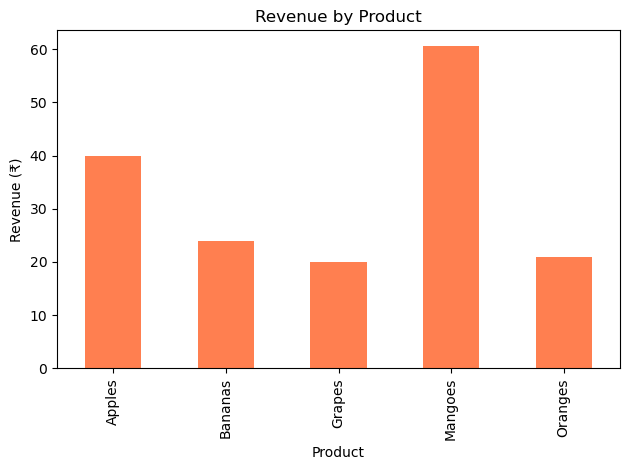

In [17]:
plt.figure(figsize=(8,5))
df.plot(kind='bar', x='product', y='revenue', color='coral', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

In [19]:
conn.close()